# Plantalyze model - Arquitectura 2 v3
Modelo de machine learning para detección de especies de plantas a partir de imágenes.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import kagglehub

 # Hiperparámetros

In [2]:
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
LEARNING_RATE = 0.0002
EPOCHS = 50

### Importar dataset

In [3]:
path = kagglehub.dataset_download("marquis03/plants-classification")

print("Path to dataset files:", path)

100%|██████████| 1.34G/1.34G [01:17<00:00, 18.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/marquis03/plants-classification/versions/1


Nota: Este dataset ya estaba separado con una distribución de **70/20/10**, 70% train, 20% test y 10% validation.

In [4]:
train_dir = path + "/train"
test_dir = path + "/test"
val_dir = path + "/val"

### Redimensionar + Data Augmentation
Redimensionar todas las imágenes de 224x224. Además de añadir data augmentation con los datos de train.


Found 21000 images belonging to 30 classes.
Found 6000 images belonging to 30 classes.
Found 3000 images belonging to 30 classes.
(32, 224, 224, 3)


<Figure size 640x480 with 0 Axes>

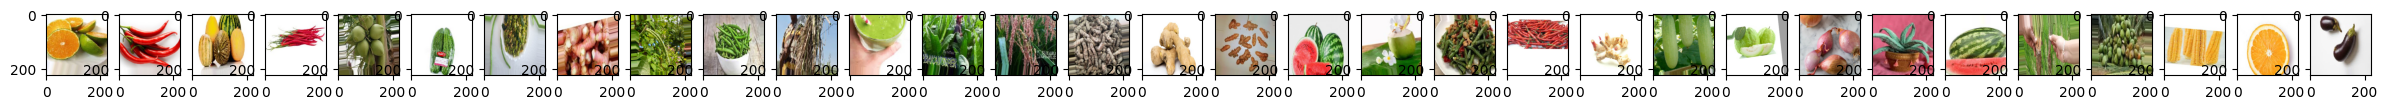

In [5]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 10,
    width_shift_range = 0.2,
    zoom_range = 0.3,
    horizontal_flip = True
    )

datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

images , labels = train_generator[0]

print(images.shape)

plt.figure()
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

In [6]:
from sklearn import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Input,
    Reshape
)

def get_model_compiled():
  model = Sequential()
  model.add(Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

  model.add(Conv2D(16, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(32, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(64, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Conv2D(128, kernel_size=3, activation="relu", padding="same"))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  model.add(Flatten())

  model.add(Dense(30, activation="softmax"))

  model.compile(optimizer="sgd",
                loss="categorical_crossentropy",
                metrics=["accuracy"])

  return model

In [7]:
model = get_model_compiled()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │       752,670 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 850,110 (3.24 MB)

 Trainable params: 850,110 (3.24 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Plantalyze

Mounted at /content/drive
/content/drive/MyDrive/Plantalyze


In [10]:
current_directory = "/content/drive/MyDrive/Plantalyze"
checkpoint_path = current_directory + "/checkpoints/checkpoint_arq2_v4.weights.h5"
checkpoint = ModelCheckpoint(filepath=checkpoint_path,
                             save_freq= "epoch",
                             save_weights_only = True,
                             verbose = 1)
early_stop = EarlyStopping(monitor='val_loss', patience=5)

In [11]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop])

Epoch 1/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.0401 - loss: 3.3906
Epoch 1: saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2_v4.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2_v4.weights.h5
657/657 ━━━━━━━━━━━━━━━━━━━━ 259s 387ms/step - accuracy: 0.0542 - loss: 3.3562 - val_accuracy: 0.0983 - val_loss: 3.1999
Epoch 2/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.1182 - loss: 3.0923
Epoch 2: saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2_v4.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Plantalyze/checkpoints/checkpoint_arq2_v4.weights.h5
657/657 ━━━━━━━━━━━━━━━━━━━━ 245s 373ms/step - accuracy: 0.1518 - loss: 2.9553 - val_accuracy: 0.2567 - val_loss: 2.5877
Epoch 3/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.2208 - loss: 2.6684
Epoch 3: saving model to /content/drive/MyDrive/Plantalyze/checkpoints

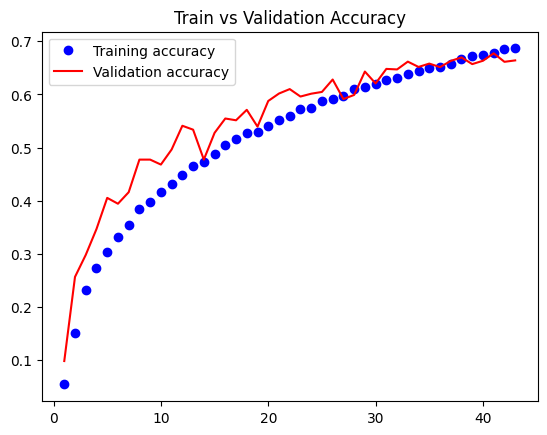

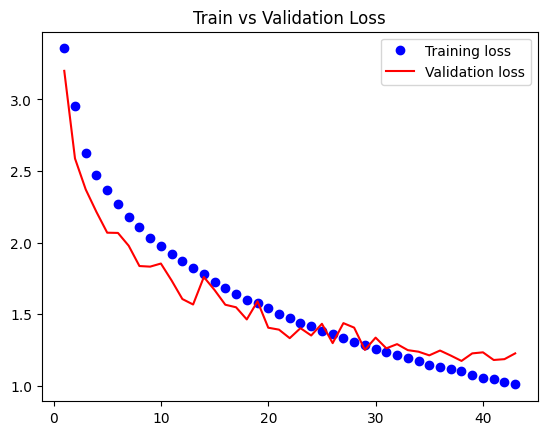

In [12]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.plot(epochs_range, acc, "bo", label="Training accuracy")
plt.plot(epochs_range, val_acc, "r", label="Validation accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()

plt.figure()

plt.plot(epochs_range, loss, "bo", label="Training loss")
plt.plot(epochs_range, val_loss, "r", label="Validation loss")
plt.title("Train vs Validation Loss")
plt.legend()

plt.show()

In [13]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc}")
print(f"Test loss: {test_loss}")

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

188/188 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.6585 - loss: 1.2380
Test accuracy: 0.6585000157356262
Test loss: 1.2380483150482178
188/188 ━━━━━━━━━━━━━━━━━━━━ 13s 68ms/step


Classification Report:
               precision    recall  f1-score   support

     aloevera       0.92      0.59      0.72       200
       banana       0.52      0.51      0.52       200
      bilimbi       0.77      0.56      0.65       200
   cantaloupe       0.38      0.44      0.41       200
      cassava       0.64      0.68      0.66       200
      coconut       0.46      0.42      0.44       200
         corn       0.81      0.77      0.78       200
     cucumber       0.68      0.82      0.74       200
      curcuma       0.69      0.79      0.73       200
     eggplant       0.74      0.61      0.67       200
     galangal       0.70      0.76      0.73       200
       ginger       0.57      0.70      0.63       200
        guava       0.58      0.74      0.65       200
         kale       0.63      0.64      0.63       200
    longbeans       0.95      0.46      0.61       200
        mango       0.61      0.38      0.46       200
        melon       0.39      0.26      0

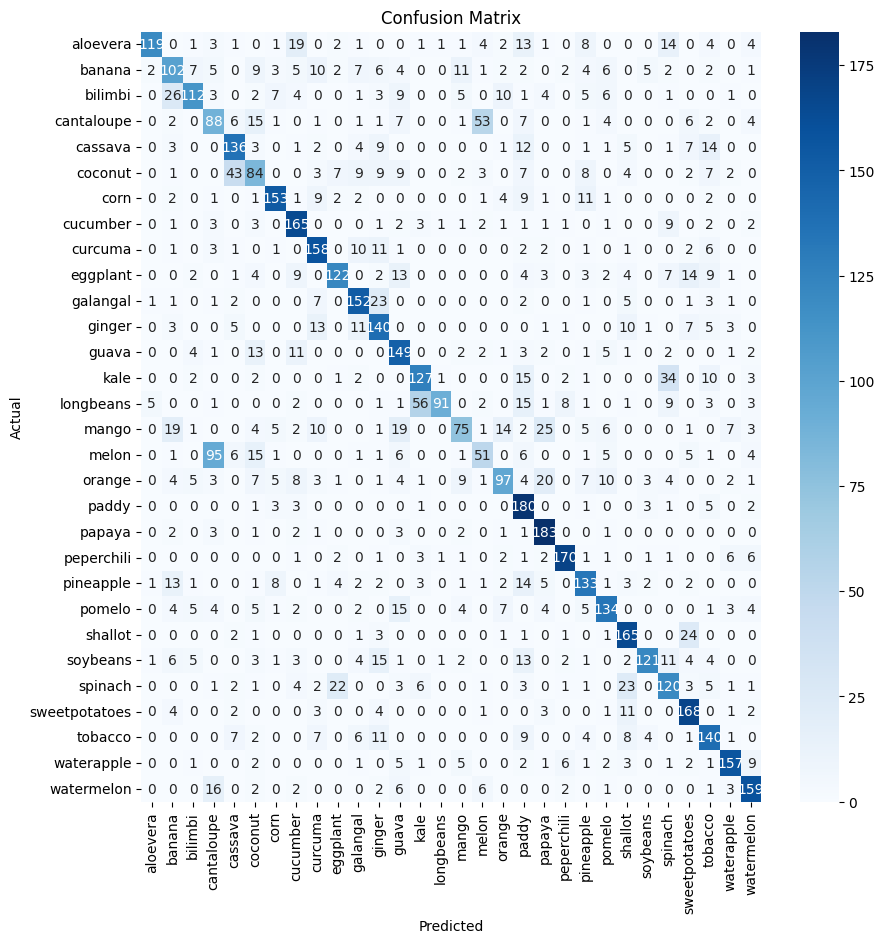

In [14]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

class_names = list(test_generator.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
)


conf_matrix = confusion_matrix(y_true, y_pred)

print("Classification Report:")
print(report)

plt.figure(figsize=(10, 10))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    # xtickrotation=45,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
